**Generated Data**

In [123]:
import pandas as pd
import numpy as np


In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

In [125]:
import random
import csv

random.seed(42)

# ---------- 1. بيانات العربيات (بسيطة) ----------
def generate_vehicles(n=20):
    vehicle_types = ["car", "van", "bus"]
    consumption_range = {   # لتر لكل 100 كم (حسب نوع العربية)
        "car": (6, 9),
        "van": (9, 13),
        "bus": (18, 28),
    }

    vehicles = []
    for i in range(n):
        vtype = random.choice(vehicle_types)
        low, high = consumption_range[vtype]
        vehicle = {
            "vehicle_id": f"VEH-{i+1}",
            "type": vtype,
            "nominal_l_per_100km": round(random.uniform(low, high), 1),
        }
        vehicles.append(vehicle)
    return vehicles


# ---------- 2. بيانات الرحلات المكتملة ----------
def generate_trips(vehicles, n=400):
    trips = []
    for i in range(n):
        v = random.choice(vehicles)  # نختار عربية عشوائية
        distance_km = round(random.uniform(5, 200), 1)

        # الـ baseline: الصيغة البسيطة من المستند
        baseline_liters = distance_km * v["nominal_l_per_100km"] / 100

        # الاستهلاك "الفعلي" = الـ baseline + شوية اختلاف عشوائي
        # (عشان نحاكي إن الواقع مش أبدًا مطابق للصيغة 100%)
        noise = random.uniform(-0.15, 0.25)   # يعني الفرق ما بين -15% و +25%
        actual_liters = round(baseline_liters * (1 + noise), 2)

        trip = {
            "trip_id": f"TRIP-{i+1}",
            "vehicle_id": v["vehicle_id"],
            "distance_km": distance_km,
            "baseline_liters_estimate": round(baseline_liters, 2),
            "actual_liters_used": actual_liters,
        }
        trips.append(trip)
    return trips


# ---------- 3. حفظ البيانات في ملفات CSV ----------
def save_csv(data, filename):
    with open(filename, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=data[0].keys())
        writer.writeheader()
        writer.writerows(data)


vehicles = generate_vehicles(20)
trips = generate_trips(vehicles, 400)

save_csv(vehicles, "seed_vehicles.csv")
save_csv(trips, "seed_completed_trips.csv")

print("تم توليد", len(vehicles), "عربية و", len(trips), "رحلة")

تم توليد 20 عربية و 400 رحلة


In [126]:
vehicles = pd.read_csv('/content/seed_vehicles.csv')
trips = pd.read_csv('/content/seed_completed_trips.csv')

In [127]:
merged = trips.merge(vehicles , on = 'vehicle_id',how = 'left')

In [128]:
merged.head()

,trip_id,vehicle_id,distance_km,baseline_liters_estimate,actual_liters_used,type,nominal_l_per_100km
0,TRIP-1,VEH-18,29.3,2.75,3.36,van,9.4
1,TRIP-2,VEH-3,112.6,7.21,8.52,car,6.4
2,TRIP-3,VEH-20,177.7,14.57,14.49,car,8.2
3,TRIP-4,VEH-7,142.4,9.54,8.28,car,6.7
4,TRIP-5,VEH-8,155.7,37.37,46.49,bus,24.0


In [129]:
merged.isnull().sum()

,0
trip_id,0
vehicle_id,0
distance_km,0
baseline_liters_estimate,0
actual_liters_used,0
type,0
nominal_l_per_100km,0


In [130]:
print(merged['type'].value_counts())


type
bus    141
car    140
van    119
Name: count, dtype: int64


In [131]:
merged.duplicated().sum()


np.int64(0)

In [132]:
type_info = merged.groupby('type')[['baseline_liters_estimate','actual_liters_used','nominal_l_per_100km']].mean()

**Fuel Consumption Analysis by Vehicle Type Code**

In [133]:
type_info

,baseline_liters_estimate,actual_liters_used,nominal_l_per_100km
type,,,
bus,21.534752,22.854539,21.635461
car,8.055429,8.513500,7.915714
van,10.808235,11.206471,9.968067


**Fuel Consumption Analysis by Vehicle Type Visual**

<Axes: xlabel='type'>

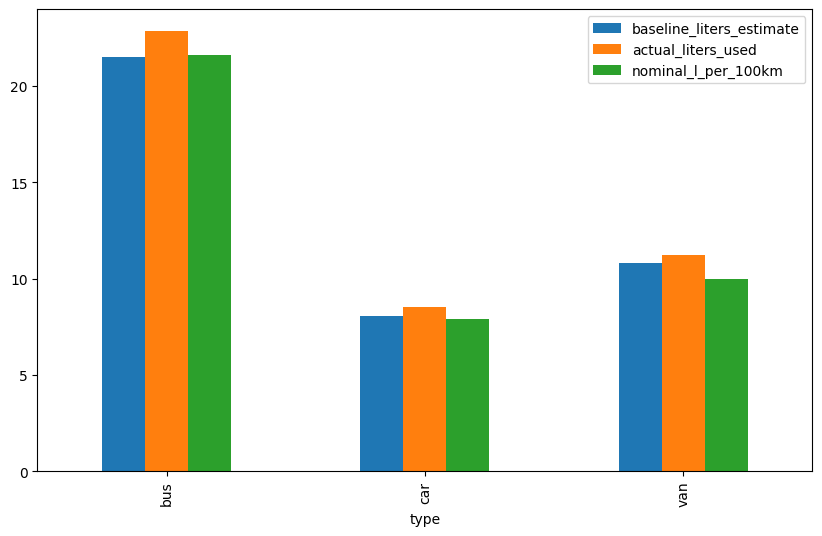

In [134]:
type_info.plot(kind = 'bar',figsize=(10, 6))

In [135]:
dis_mean = merged.groupby('type')[['distance_km','actual_liters_used','baseline_liters_estimate']].mean().round(2)

In [136]:
dis_mean

,distance_km,actual_liters_used,baseline_liters_estimate
type,,,
bus,99.08,22.85,21.53
car,101.41,8.51,8.06
van,108.13,11.21,10.81


In [137]:
# corr

merged[['distance_km','actual_liters_used']].corr()

,distance_km,actual_liters_used
distance_km,1.000000,0.699903
actual_liters_used,0.699903,1.000000


In [138]:
dis_n_a = merged[['distance_km','nominal_l_per_100km','actual_liters_used']].corr()

In [139]:
dis_n_a

,distance_km,nominal_l_per_100km,actual_liters_used
distance_km,1.000000,-0.022185,0.699903
nominal_l_per_100km,-0.022185,1.000000,0.583877
actual_liters_used,0.699903,0.583877,1.000000


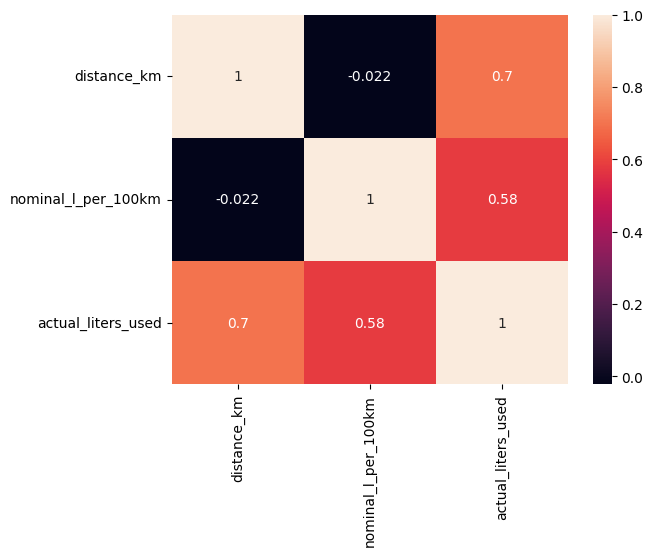

In [140]:
sns.heatmap(dis_n_a,annot=True)
plt.show()

In [141]:
merged['error'] = merged['actual_liters_used'] - merged['baseline_liters_estimate']
merged['pct_error'] = (merged['error'] / merged['baseline_liters_estimate']) * 100

print(merged.groupby('type')[['error', 'pct_error']].mean().round(2))

      error  pct_error
type                  
bus    1.32       6.00
car    0.46       6.30
van    0.40       4.17


In [142]:
summary = merged.groupby('type').agg(
    trip_count=('trip_id', 'count'),
    avg_distance=('distance_km', 'mean'),
    avg_actual=('actual_liters_used', 'mean'),
    avg_baseline=('baseline_liters_estimate', 'mean'),
    avg_pct_error=('pct_error', 'mean')
).round(2)

print(summary)

      trip_count  avg_distance  avg_actual  avg_baseline  avg_pct_error
type                                                                   
bus          141         99.08       22.85         21.53           6.00
car          140        101.41        8.51          8.06           6.30
van          119        108.13       11.21         10.81           4.17


In [143]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# ==================================================
# 1. تجهيز البيانات (X = المميزات, y = الهدف)
# ==================================================
X = merged[['distance_km', 'nominal_l_per_100km']]
y = merged['actual_liters_used']
baseline = merged['baseline_liters_estimate']

# ==================================================
# 2. تقسيم البيانات: تدريب (80%) واختبار (20%)
# ==================================================
X_train, X_test, y_train, y_test, baseline_train, baseline_test = train_test_split(
    X, y, baseline, test_size=0.2, random_state=42
)

print(f"عدد بيانات التدريب: {len(X_train)}")
print(f"عدد بيانات الاختبار: {len(X_test)}")

# ==================================================
# 3. تدريب الموديل
# ==================================================
model = LinearRegression()
model.fit(X_train, y_train)

model_predictions = model.predict(X_test)

# ==================================================
# 4. حساب MAE و MAPE
# ==================================================
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

baseline_mae = mean_absolute_error(y_test, baseline_test)
model_mae = mean_absolute_error(y_test, model_predictions)

baseline_mape = mape(y_test, baseline_test)
model_mape = mape(y_test, model_predictions)

# ==================================================
# 5. عرض المقارنة والقرار
# ==================================================
print("\n===== المقارنة على بيانات الاختبار =====")
print(f"الباز لاين  → MAE: {baseline_mae:.2f} لتر   |  MAPE: {baseline_mape:.1f}%")
print(f"الموديل     → MAE: {model_mae:.2f} لتر   |  MAPE: {model_mape:.1f}%")

if model_mae < baseline_mae:
    improvement = (baseline_mae - model_mae) / baseline_mae * 100
    print(f"\n✅ الموديل أحسن من الباز لاين بنسبة {improvement:.1f}%")
else:
    decline = (model_mae - baseline_mae) / baseline_mae * 100
    print(f"\n⚠️ الموديل أسوأ من الباز لاين بنسبة {decline:.1f}%")

# ==================================================
# 6. تفاصيل إضافية (اختياري)
# ==================================================
print(f"\nR² على التدريب: {model.score(X_train, y_train):.3f}")
print(f"R² على الاختبار: {model.score(X_test, y_test):.3f}")

عدد بيانات التدريب: 320
عدد بيانات الاختبار: 80

===== المقارنة على بيانات الاختبار =====
الباز لاين  → MAE: 1.57 لتر   |  MAPE: 10.6%
الموديل     → MAE: 3.34 لتر   |  MAPE: 66.8%

⚠️ الموديل أسوأ من الباز لاين بنسبة 113.3%

R² على التدريب: 0.846
R² على الاختبار: 0.862


In [122]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# ==================================================
# 1. تجهيز البيانات (X = المميزات, y = الهدف)
# ==================================================
X = merged[['distance_km', 'nominal_l_per_100km']]
y = merged['actual_liters_used']
baseline = merged['baseline_liters_estimate']

# ==================================================
# 2. تقسيم البيانات: تدريب (80%) واختبار (20%)
# ==================================================
X_train, X_test, y_train, y_test, baseline_train, baseline_test = train_test_split(
    X, y, baseline, test_size=0.2, random_state=42
)

print(f"عدد بيانات التدريب: {len(X_train)}")
print(f"عدد بيانات الاختبار: {len(X_test)}")

# ==================================================
# 3. تدريب الموديل
# ==================================================
model = LinearRegression()
model.fit(X_train, y_train)

model_predictions = model.predict(X_test)

# ==================================================
# 4. حساب MAE و MAPE (النسخة المُصلحة - بتتجنب مشكلة القيم الصغيرة)
# ==================================================
def mape_safe(y_true, y_pred, min_threshold=2.0):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true >= min_threshold   # نستبعد الرحلات القصيرة جدًا من الحساب فقط
    excluded = (~mask).sum()
    if excluded > 0:
        print(f"(تم استبعاد {excluded} رحلة من حساب MAPE لأن استهلاكها أقل من {min_threshold} لتر)")
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

baseline_mae = mean_absolute_error(y_test, baseline_test)
model_mae = mean_absolute_error(y_test, model_predictions)

baseline_mape = mape_safe(y_test, baseline_test)
model_mape = mape_safe(y_test, model_predictions)

# ==================================================
# 5. عرض المقارنة والقرار
# ==================================================
print("\n===== المقارنة على بيانات الاختبار =====")
print(f"الباز لاين  → MAE: {baseline_mae:.2f} لتر   |  MAPE: {baseline_mape:.1f}%")
print(f"الموديل     → MAE: {model_mae:.2f} لتر   |  MAPE: {model_mape:.1f}%")

if model_mae < baseline_mae:
    improvement = (baseline_mae - model_mae) / baseline_mae * 100
    print(f"\n✅ الموديل أحسن من الباز لاين بنسبة {improvement:.1f}%")
else:
    decline = (model_mae - baseline_mae) / baseline_mae * 100
    print(f"\n⚠️ الموديل أسوأ من الباز لاين بنسبة {decline:.1f}%")

# ==================================================
# 6. تفاصيل إضافية (اختياري)
# ==================================================
print(f"\nR² على التدريب: {model.score(X_train, y_train):.3f}")
print(f"R² على الاختبار: {model.score(X_test, y_test):.3f}")

عدد بيانات التدريب: 320
عدد بيانات الاختبار: 80
(تم استبعاد 7 رحلة من حساب MAPE لأن استهلاكها أقل من 2.0 لتر)
(تم استبعاد 7 رحلة من حساب MAPE لأن استهلاكها أقل من 2.0 لتر)

===== المقارنة على بيانات الاختبار =====
الباز لاين  → MAE: 1.57 لتر   |  MAPE: 10.3%
الموديل     → MAE: 3.34 لتر   |  MAPE: 29.6%

⚠️ الموديل أسوأ من الباز لاين بنسبة 113.3%

R² على التدريب: 0.846
R² على الاختبار: 0.862


In [144]:
# اطبع أصغر 5 قيم في y_test عشان تتأكد
print(y_test.sort_values().head(5))

# احسب الخطأ الفردي لكل رحلة، واطبع أعلى 5 قيم
individual_errors = np.abs((y_test.values - model_predictions) / y_test.values) * 100
print("أعلى 5 نسب خطأ:", np.sort(individual_errors)[-5:])

352    0.55
262    0.93
361    1.29
227    1.69
45     1.74
Name: actual_liters_used, dtype: float64
أعلى 5 نسب خطأ: [287.60191396 380.35438211 555.48749506 612.25542045 957.79616146]


In [145]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# ========== الخطوة 1: تجهيز البيانات ==========
X = merged[['distance_km', 'nominal_l_per_100km']]
y = merged['actual_liters_used']
baseline = merged['baseline_liters_estimate']

# ========== الخطوة 2: التقسيم ==========
X_train, X_test, y_train, y_test, baseline_train, baseline_test = train_test_split(
    X, y, baseline, test_size=0.2, random_state=42
)

# ========== الخطوة 3: التدريب ==========
model = LinearRegression()
model.fit(X_train, y_train)

# ========== الخطوة 4: التوقع (لازم يتحسب هنا فورًا بعد التدريب مباشرة) ==========
model_predictions = model.predict(X_test)

# ========== الخطوة 5: التحقق - هل الأرقام متوافقة مع بعض؟ ==========
mae_value = mean_absolute_error(y_test, model_predictions)
r2_value = r2_score(y_test, model_predictions)

print("===== النتيجة النهائية (من نفس اللحظة، بدون أي خلايا قديمة) =====")
print(f"MAE: {mae_value:.2f}")
print(f"R²: {r2_value:.3f}")

# ========== الخطوة 6: مقارنة سريعة يدوية للتأكد ==========
print("\nمقارنة أول 10 رحلات (فعلي مقابل متوقع):")
for i in range(10):
    actual = y_test.values[i]
    predicted = model_predictions[i]
    print(f"فعلي: {actual:.2f}  |  متوقع: {predicted:.2f}  |  الفرق: {abs(actual-predicted):.2f}")

===== النتيجة النهائية (من نفس اللحظة، بدون أي خلايا قديمة) =====
MAE: 3.34
R²: 0.862

مقارنة أول 10 رحلات (فعلي مقابل متوقع):
فعلي: 4.42  |  متوقع: 1.38  |  الفرق: 3.04
فعلي: 14.48  |  متوقع: 17.40  |  الفرق: 2.92
فعلي: 17.90  |  متوقع: 20.24  |  الفرق: 2.34
فعلي: 36.30  |  متوقع: 27.59  |  الفرق: 8.71
فعلي: 23.31  |  متوقع: 24.03  |  الفرق: 0.72
فعلي: 14.63  |  متوقع: 15.62  |  الفرق: 0.99
فعلي: 5.12  |  متوقع: 11.70  |  الفرق: 6.58
فعلي: 11.61  |  متوقع: 12.24  |  الفرق: 0.63
فعلي: 21.96  |  متوقع: 20.26  |  الفرق: 1.70
فعلي: 13.78  |  متوقع: 13.72  |  الفرق: 0.06


In [146]:
print(y_test.mean())
print(y_test.describe())

15.676875
count    80.000000
mean     15.676875
std      11.485456
min       0.550000
25%       6.600000
50%      13.225000
75%      21.892500
max      45.730000
Name: actual_liters_used, dtype: float64
